DATASET INFORMATION
Dataset shape: (569, 30)
Number of features: 30
Number of samples: 569

Target classes:
['malignant' 'benign']

First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280   

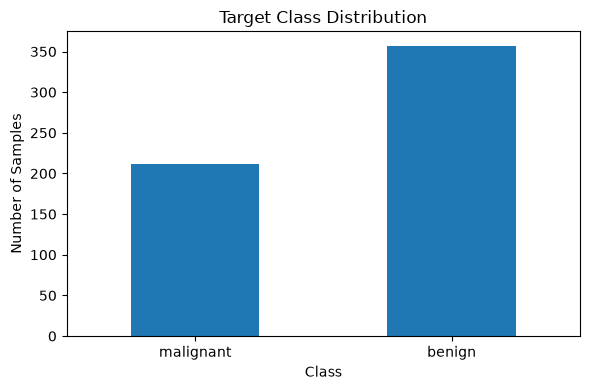


TRAIN-TEST SPLIT
Training samples: 455
Testing samples: 114

TRAINING LOGISTIC REGRESSION

TRAINING RANDOM FOREST

--------------------------------------------------
Logistic Regression
--------------------------------------------------
Accuracy : 0.9825
Precision: 0.9861
Recall   : 0.9861
F1 Score : 0.9861
ROC-AUC  : 0.9954

--------------------------------------------------
Random Forest
--------------------------------------------------
Accuracy : 0.9561
Precision: 0.9589
Recall   : 0.9722
F1 Score : 0.9655
ROC-AUC  : 0.9937

MODEL COMPARISON
              Model  Accuracy  Precision   Recall  F1 Score  ROC-AUC
Logistic Regression  0.982456   0.986111 0.986111  0.986111 0.995370
      Random Forest  0.956140   0.958904 0.972222  0.965517 0.993717

5-FOLD CROSS-VALIDATION
Logistic Regression CV Accuracy: 0.9807
Random Forest CV Accuracy: 0.9561

BEST MODEL
Selected Model: Logistic Regression

CLASSIFICATION REPORT
              precision    recall  f1-score   support

   malignant   

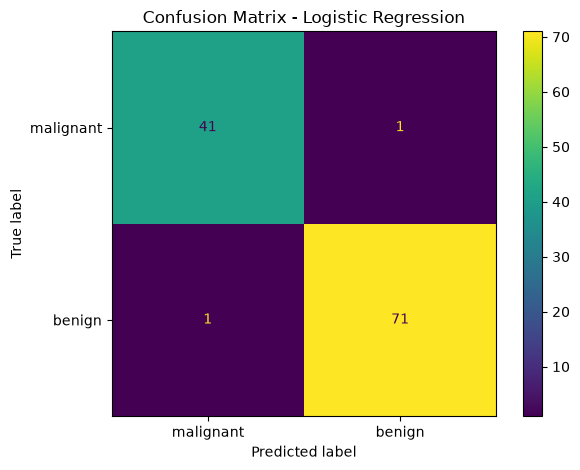

<Figure size 700x500 with 0 Axes>

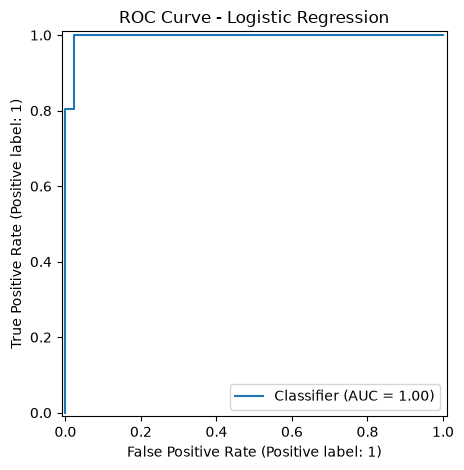


MODEL SAVED
Saved file: model.pkl

Saved model loaded successfully.

SAMPLE PREDICTION
Predicted class: malignant
Actual class: malignant

PROJECT COMPLETED SUCCESSFULLY
Dataset: Breast Cancer Dataset
Models Compared:
1. Logistic Regression
2. Random Forest
Best Model: Logistic Regression
Best Model Accuracy: 0.9825

Generated files:
- model.pkl

Task 1 ML Classification completed successfully.


In [1]:
# ============================================================
# INTERNSPARK AI INTERNSHIP
# TASK 1 - ML CLASSIFICATION PROJECT
# ============================================================

# -----------------------------
# 1. IMPORT LIBRARIES
# -----------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

import joblib


# ============================================================
# 2. LOAD DATASET
# ============================================================

data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name="target")

print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("Dataset shape:", X.shape)
print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

print("\nTarget classes:")
print(data.target_names)

print("\nFirst 5 rows:")
print(X.head())


# ============================================================
# 3. CHECK MISSING VALUES
# ============================================================

print("\n" + "=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)

missing_values = X.isnull().sum()

print(missing_values)

if missing_values.sum() == 0:
    print("\nNo missing values found.")
else:
    print("\nMissing values are present.")


# ============================================================
# 4. BASIC DATA STATISTICS
# ============================================================

print("\n" + "=" * 60)
print("DATASET STATISTICS")
print("=" * 60)

print(X.describe())


# ============================================================
# 5. TARGET DISTRIBUTION
# ============================================================

print("\n" + "=" * 60)
print("TARGET DISTRIBUTION")
print("=" * 60)

print(y.value_counts())

plt.figure(figsize=(6, 4))

y.value_counts().sort_index().plot(
    kind="bar"
)

plt.title("Target Class Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Samples")
plt.xticks(
    ticks=[0, 1],
    labels=data.target_names,
    rotation=0
)

plt.tight_layout()
plt.show()


# ============================================================
# 6. TRAIN-TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])


# ============================================================
# 7. CREATE MODELS
# ============================================================

# Logistic Regression with StandardScaler
logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("classifier", LogisticRegression(max_iter=5000))
])

# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)


# ============================================================
# 8. TRAIN LOGISTIC REGRESSION
# ============================================================

print("\n" + "=" * 60)
print("TRAINING LOGISTIC REGRESSION")
print("=" * 60)

logistic_model.fit(X_train, y_train)

logistic_pred = logistic_model.predict(X_test)
logistic_prob = logistic_model.predict_proba(X_test)[:, 1]


# ============================================================
# 9. TRAIN RANDOM FOREST
# ============================================================

print("\n" + "=" * 60)
print("TRAINING RANDOM FOREST")
print("=" * 60)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]


# ============================================================
# 10. FUNCTION TO CALCULATE METRICS
# ============================================================

def calculate_metrics(model_name, y_true, y_pred, y_prob):

    accuracy = accuracy_score(y_true, y_pred)

    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_true,
        y_prob
    )

    print("\n" + "-" * 50)
    print(model_name)
    print("-" * 50)

    print("Accuracy :", round(accuracy, 4))
    print("Precision:", round(precision, 4))
    print("Recall   :", round(recall, 4))
    print("F1 Score :", round(f1, 4))
    print("ROC-AUC  :", round(roc_auc, 4))

    return {
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    }


# ============================================================
# 11. EVALUATE BOTH MODELS
# ============================================================

logistic_results = calculate_metrics(
    "Logistic Regression",
    y_test,
    logistic_pred,
    logistic_prob
)

rf_results = calculate_metrics(
    "Random Forest",
    y_test,
    rf_pred,
    rf_prob
)


# ============================================================
# 12. COMPARE RESULTS
# ============================================================

results = pd.DataFrame([
    logistic_results,
    rf_results
])

print("\n" + "=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

print(results.to_string(index=False))


# ============================================================
# 13. CROSS-VALIDATION
# ============================================================

print("\n" + "=" * 60)
print("5-FOLD CROSS-VALIDATION")
print("=" * 60)

logistic_cv = cross_val_score(
    logistic_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

rf_cv = cross_val_score(
    rf_model,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print(
    "Logistic Regression CV Accuracy:",
    round(logistic_cv.mean(), 4)
)

print(
    "Random Forest CV Accuracy:",
    round(rf_cv.mean(), 4)
)


# ============================================================
# 14. SELECT BEST MODEL
# ============================================================

if rf_results["F1 Score"] >= logistic_results["F1 Score"]:

    best_model = rf_model
    best_model_name = "Random Forest"
    best_prediction = rf_pred

else:

    best_model = logistic_model
    best_model_name = "Logistic Regression"
    best_prediction = logistic_pred


print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print("Selected Model:", best_model_name)


# ============================================================
# 15. CLASSIFICATION REPORT
# ============================================================

print("\n" + "=" * 60)
print("CLASSIFICATION REPORT")
print("=" * 60)

print(
    classification_report(
        y_test,
        best_prediction,
        target_names=data.target_names
    )
)


# ============================================================
# 16. CONFUSION MATRIX
# ============================================================

print("\n" + "=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)

cm = confusion_matrix(
    y_test,
    best_prediction
)

print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=data.target_names
)

disp.plot()

plt.title(
    "Confusion Matrix - " + best_model_name
)

plt.tight_layout()
plt.show()


# ============================================================
# 17. ROC CURVE
# ============================================================

plt.figure(figsize=(7, 5))

if best_model_name == "Random Forest":

    RocCurveDisplay.from_predictions(
        y_test,
        rf_prob
    )

else:

    RocCurveDisplay.from_predictions(
        y_test,
        logistic_prob
    )

plt.title(
    "ROC Curve - " + best_model_name
)

plt.tight_layout()
plt.show()


# ============================================================
# 18. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

if best_model_name == "Random Forest":

    feature_importance = pd.DataFrame({
        "Feature": X.columns,
        "Importance": rf_model.feature_importances_
    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    print("\n" + "=" * 60)
    print("TOP 10 IMPORTANT FEATURES")
    print("=" * 60)

    print(
        feature_importance.head(10).to_string(
            index=False
        )
    )

    plt.figure(figsize=(10, 6))

    plt.barh(
        feature_importance.head(10)["Feature"][::-1],
        feature_importance.head(10)["Importance"][::-1]
    )

    plt.title("Top 10 Feature Importances")
    plt.xlabel("Importance")
    plt.ylabel("Feature")

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. SAVE BEST MODEL
# ============================================================

joblib.dump(
    best_model,
    "model.pkl"
)

print("\n" + "=" * 60)
print("MODEL SAVED")
print("=" * 60)

print("Saved file: model.pkl")


# ============================================================
# 20. LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    "model.pkl"
)

print("\nSaved model loaded successfully.")


# ============================================================
# 21. TEST ONE SAMPLE
# ============================================================

sample = X_test.iloc[[0]]

sample_prediction = loaded_model.predict(
    sample
)

print("\n" + "=" * 60)
print("SAMPLE PREDICTION")
print("=" * 60)

print("Predicted class:",
      data.target_names[sample_prediction[0]])

print("Actual class:",
      data.target_names[y_test.iloc[0]])


# ============================================================
# 22. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 60)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 60)

print("Dataset: Breast Cancer Dataset")
print("Models Compared:")
print("1. Logistic Regression")
print("2. Random Forest")
print("Best Model:", best_model_name)

print(
    "Best Model Accuracy:",
    round(
        accuracy_score(
            y_test,
            best_prediction
        ),
        4
    )
)

print("\nGenerated files:")
print("- model.pkl")

print("\nTask 1 ML Classification completed successfully.")